A condição de estabilidade foi satisfeita.
lambda = 0.3094613485101719


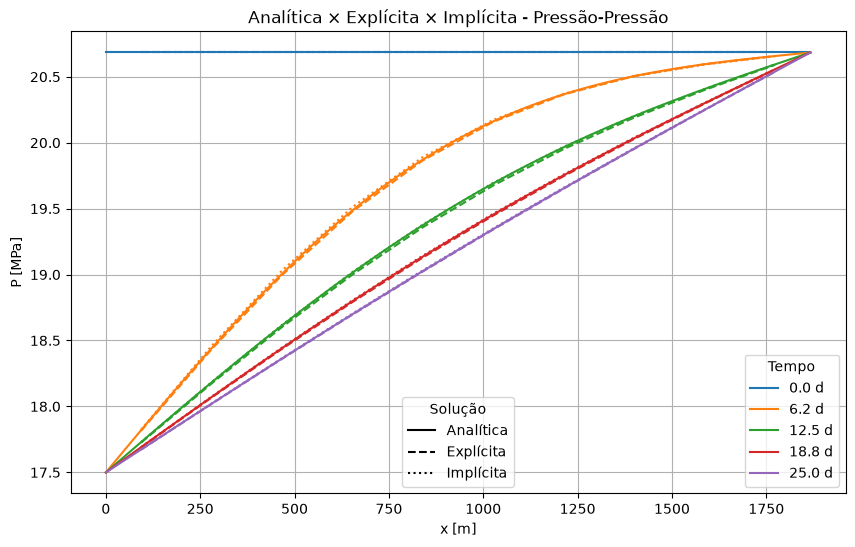

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from analytical.transiente_L1d_PP import linear_trans_1d_PP
from mdf.explicita import explicita_1d_PP
from mdf.implicita import implicita_1d_PP


# parâmetros

Pw = 17.499e6             # pressão em x = 0 [Pa]
p0 = 20.684e6             # pressão inicial e pressão em x = L [Pa]

A_R = 3484800             # área do reservatório [m²]
L = np.sqrt(A_R)          # comprimento [m]

k = 339 * 9.869233e-16    # permeabilidade [m²]
phi = 0.22
ct = 3.046e-9
mu = 1.0e-3

t_d = 25                  # tempo final [dias]
t_final = t_d * 86400     # tempo final [s]

n_modos = 100

h = 4.572
largura = L


# solução analítica

x_an, t_an, X, T, P_an = linear_trans_1d_PP(
    p0,
    Pw,
    L,
    k,
    phi,
    ct,
    mu,
    t_final,
    n_modos
)


# malha numérica

nx = 10
nt = 100


# solução explícita

x_exp, t_exp, P_exp, lambd = explicita_1d_PP(
    p0,
    Pw,
    h,
    L,
    largura,
    k,
    phi,
    ct,
    mu,
    t_final,
    nx,
    nt
)

print("lambda =", lambd)


# solução implícita

metodo = "TDMA"  # opções: "TDMA", "Gauss", "Jacobi" ou "Scipy"

x_imp, t_imp, P_imp, lambd_imp = implicita_1d_PP(
    p0,
    Pw,
    h,
    L,
    largura,
    k,
    phi,
    ct,
    mu,
    t_final,
    nx,
    nt,
    metodo=metodo
)


# comparação analítica x explícita x implícita

tempos_escolhidos = np.linspace(0, t_d, 5)

plt.figure(figsize=(10, 6))

cores = []

for tempo in tempos_escolhidos:

    t_escolhido = tempo * 86400

    i_an = np.argmin(np.abs(t_an - t_escolhido))
    i_exp = np.argmin(np.abs(t_exp - t_escolhido))
    i_imp = np.argmin(np.abs(t_imp - t_escolhido))

    # analítica
    linha, = plt.plot(
        x_an,
        P_an[i_an, :] / 1e6,
        "-"
    )

    cor = linha.get_color()
    cores.append(cor)

    # explícita
    plt.plot(
        x_exp,
        P_exp[i_exp, :] / 1e6,
        "--",
        color=cor
    )

    # implícita
    plt.plot(
        x_imp,
        P_imp[i_imp, :] / 1e6,
        ":",
        color=cor
    )


plt.xlabel("x [m]")
plt.ylabel("P [MPa]")
plt.title("Analítica × Explícita × Implícita - Pressão-Pressão")
plt.grid()


# legenda dos tempos

linhas_tempo = []

for tempo, cor in zip(tempos_escolhidos, cores):

    linha_tempo, = plt.plot(
        [],
        [],
        color=cor,
        label=f"{tempo:.1f} d"
    )

    linhas_tempo.append(linha_tempo)


legenda_tempo = plt.legend(
    handles=linhas_tempo,
    title="Tempo",
    loc="lower right"
)

plt.gca().add_artist(legenda_tempo)


# legenda das soluções

analitica, = plt.plot([], [], "k-", label="Analítica")
explicita, = plt.plot([], [], "k--", label="Explícita")
implicita, = plt.plot([], [], "k:", label="Implícita")

plt.legend(
    handles=[analitica, explicita, implicita],
    title="Solução",
    loc="lower center"
)

plt.show()